# Morphology Profile Prediction

In order to evaluate our ability to predict morphology from functional data we attempt to fit every feature in the (control-normalized) CellProfiler profiles using shallow models.

In this notebook we fit and predict per-well profiles, that are obtained by averaging the well profiles for the gene knockouts

In [1]:
# Turn off to get plots only
RUN_PREDICTIONS = False

## Load profiles

In [2]:
from pathlib import Path
import pandas as pd

data_folder = Path('/ua/ml-group/igvf/repos/morphology-prediction/data/cpg0016/version_2024-04-15')

# Load profiles
normalized_profiles = pd.read_parquet(data_folder/'normalized_profiles').set_index(['Metadata_Plate', 'Metadata_Well'])

In [3]:
# Get the list of knockouts
knockouts = normalized_profiles[normalized_profiles['Metadata_Perturbation'] == 'CRISPR-trt']['Metadata_Symbol'].drop_duplicates()
knockouts

Metadata_Plate  Metadata_Well
CP-CC9-R1-01    A03              ARHGEF7
                A04                 ST13
                A05                 GPHN
                A06                 EXT2
                A07                SNUPN
                                  ...   
CP-CC9-R2-20    O16              SMARCA4
CP-CC9-R2-21    L08                TGIF1
CP-CC9-R2-26    N09               LRSAM1
CP-CC9-R6-02    C09               INPP5B
CP-CC9-R7-02    J10               SPTLC1
Name: Metadata_Symbol, Length: 7975, dtype: object

In [4]:
# Should we select only knockouts first?
profile_columns = normalized_profiles.columns[~normalized_profiles.columns.str.startswith('Metadata')]

# Compute average gene profiles
profiles_groupby = normalized_profiles.groupby('Metadata_Symbol')[profile_columns]
gene_profiles = profiles_groupby.mean()

# Compute gene profile variances
gene_profile_sd = profiles_groupby.std()

In [5]:
gene_profiles

,Cells_AreaShape_Area,Cells_AreaShape_BoundingBoxArea,Cells_AreaShape_BoundingBoxMaximum_X,Cells_AreaShape_BoundingBoxMaximum_Y,Cells_AreaShape_BoundingBoxMinimum_X,Cells_AreaShape_BoundingBoxMinimum_Y,Cells_AreaShape_Center_X,Cells_AreaShape_Center_Y,Cells_AreaShape_Compactness,Cells_AreaShape_Eccentricity,...,Nuclei_Texture_Variance_RNA_10_02_256,Nuclei_Texture_Variance_RNA_10_03_256,Nuclei_Texture_Variance_RNA_3_00_256,Nuclei_Texture_Variance_RNA_3_01_256,Nuclei_Texture_Variance_RNA_3_02_256,Nuclei_Texture_Variance_RNA_3_03_256,Nuclei_Texture_Variance_RNA_5_00_256,Nuclei_Texture_Variance_RNA_5_01_256,Nuclei_Texture_Variance_RNA_5_02_256,Nuclei_Texture_Variance_RNA_5_03_256
Metadata_Symbol,,,,,,,,,,,,,,,,,,,,,
A2M,4.271224e+00,4.075763e+00,-2.039462e+00,-1.495266e+00,-2.734124e+00,-2.749721e+00,-2.405318e+00,-2.145979e+00,3.379102e+00,1.812960e+00,...,-1.278281e-01,-1.234162e-01,-1.661557e-01,-1.617862e-01,-1.665350e-01,-1.617394e-01,-1.565070e-01,-1.438597e-01,-1.577964e-01,-1.494244e-01
A3GALT2,5.441730e+00,5.664170e+00,-1.762820e-01,-5.956194e-01,-1.053049e+00,-1.524598e+00,-6.210147e-01,-1.062760e+00,4.335549e+00,4.707353e+00,...,1.800513e+00,1.839104e+00,1.785617e+00,1.775837e+00,1.778829e+00,1.773106e+00,1.776136e+00,1.771840e+00,1.769721e+00,1.774792e+00
A4GALT,7.633246e+00,7.461262e+00,-6.852436e-01,-2.046467e+00,-1.856820e+00,-3.872146e+00,-1.276147e+00,-2.976838e+00,4.733387e+00,5.299724e+00,...,2.352426e+00,2.370462e+00,2.315699e+00,2.310461e+00,2.308184e+00,2.313313e+00,2.318685e+00,2.318679e+00,2.310203e+00,2.327785e+00
A4GNT,3.883424e+00,3.911681e+00,-1.057684e+00,-1.570846e+00,-1.635256e+00,-2.135809e+00,-1.361475e+00,-1.869386e+00,3.193734e+00,3.018797e+00,...,-4.630077e-02,-7.236734e-02,-8.697351e-02,-8.018964e-02,-8.959037e-02,-7.585055e-02,-7.080548e-02,-5.965750e-02,-7.443602e-02,-5.193674e-02
AACS,4.806002e+00,4.718809e+00,-1.814385e-01,-1.160519e+00,-9.837074e-01,-1.880670e+00,-5.882301e-01,-1.538414e+00,3.289793e+00,3.438077e+00,...,1.641492e+00,1.681031e+00,1.605606e+00,1.604034e+00,1.603862e+00,1.606279e+00,1.603759e+00,1.609158e+00,1.610295e+00,1.619937e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZSCAN5A,3.391835e+00,3.508841e+00,-5.331033e-01,-7.639250e-01,-1.496517e+00,-1.807709e+00,-1.022573e+00,-1.308912e+00,2.699000e+00,2.628308e+00,...,7.980748e+00,7.868014e+00,8.015474e+00,8.023442e+00,8.002563e+00,8.026239e+00,8.036328e+00,8.012364e+00,8.018636e+00,8.017954e+00
ZSCAN9,7.168445e+00,7.873502e+00,-4.965104e+00,-9.553642e+00,-5.574758e+00,-1.071264e+01,-5.275126e+00,-1.022032e+01,2.297388e+01,6.700232e+00,...,1.372931e+00,1.462030e+00,1.354033e+00,1.334094e+00,1.349754e+00,1.329911e+00,1.334594e+00,1.337446e+00,1.322950e+00,1.327560e+00
ZSWIM2,3.894485e+00,4.119784e+00,-1.309242e+00,-1.434214e+00,-2.291130e+00,-2.317642e+00,-1.815396e+00,-1.900331e+00,3.598190e+00,4.919179e+00,...,3.124950e+00,3.154758e+00,3.133706e+00,3.117666e+00,3.133654e+00,3.123436e+00,3.116132e+00,3.111622e+00,3.119131e+00,3.126571e+00


## Build feature vectors
Next we collect our functional features

In [6]:
from dataloader import FunctionalData

functional_data_root = Path('/ua/ml-group/igvf/data')

# Gene abundances
fd = FunctionalData(
    abundances_path=functional_data_root / 'cellular-localization' / 'gene_abundances_U2OS.tsv',
    undetected_path=functional_data_root / 'cellular-localization' / 'undetected_genes_U2OS.tsv',
    subcellular_path=functional_data_root / 'subcellular-localization' / 'uniprot_reactome_hpa_merged.tsv',
    go_path=functional_data_root / 'GO_Embeddings' / 'go_embedding_64.csv'
)

/scratch/yuriy/morphology-prediction/skl-models/dataloader.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abundance_df.loc[:, 'Protein present'] = 1


### Assembling the feature vectors for genes

In [7]:
# Link feature vectors to gene vectors
features_and_profiles = fd.gene_features.merge(
    gene_profiles,
    left_index=True,
    right_index=True
)

## Running predictions

We set up 10 cross-validation folds (by gene).

Only recompute results if needed. We use dates for versioning.

In [8]:
# Which version of the results to try to load
predictor_version = '2024-06-20'

from sklearn.linear_model import LinearRegression, Lasso
import xgboost as xgb

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(),
    'XGB': xgb.XGBRegressor(tree_method='hist')
}

In [9]:
model_paths = {
    (name, group): Path(f'results/genes/Predict {name} {group} {predictor_version}.csv')
    for name in models.keys()
    for group in fd.feature_column_groups.keys()
}

models_to_train = [
    (name, group, path, models[name], fd.feature_column_groups[group])
    for (name, group), path in model_paths.items()
    if not path.exists()
]

In [10]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict

if RUN_PREDICTIONS:
    
    splits = KFold(n_splits=10, shuffle=True, random_state=20240425)

    for name, group, path, model, feature_columns in models_to_train:
        print(f'{model} fitting {group}')

        df = features_and_profiles[profile_columns].apply(
            lambda profile_component:
                cross_val_predict(
                    model,
                    features_and_profiles[feature_columns],
                    profile_component,
                    cv=splits,
                    n_jobs=-1
                )
        )

        print(f'Saving to {path}')
        df.to_csv(path)

In [11]:
# Load predictions
cv_predictions = {
    key: pd.read_csv(path, index_col=[0])
    for key, path in model_paths.items()
    if path.exists()
}

In [12]:
# Total sum of squares in profiles
profile_tss = (
    (
        features_and_profiles[profile_columns]
        - features_and_profiles[profile_columns].mean(axis='index')
    ) ** 2
).sum(axis='index')

# Compute R squared
cv_rsquared = pd.concat(
    {
        key:
            1 - ((df - features_and_profiles[profile_columns])**2).sum(axis='index') / profile_tss
        for key, df in cv_predictions.items()
    }
)

In [13]:
cv_rsquared_df = cv_rsquared.sort_values(ascending=False).to_frame(name='R Squared')
cv_rsquared_df.index.set_names(['Model', 'Group', 'Feature'], inplace=True)
cv_rsquared_df.reset_index(inplace=True)
cv_rsquared_df

,Model,Group,Feature,R Squared
0,Linear Regression,All,Cells_RadialDistribution_FracAtD_mito_tubeness...,0.166645
1,Linear Regression,All,Cells_RadialDistribution_MeanFrac_mito_tubenes...,0.165614
2,Linear Regression,All,Cells_RadialDistribution_FracAtD_mito_tubeness...,0.165357
3,Linear Regression,All,Cells_RadialDistribution_MeanFrac_mito_tubenes...,0.160988
4,Linear Regression,All,Cells_RadialDistribution_FracAtD_mito_tubeness...,0.140569
...,...,...,...,...
99955,XGB,All,Nuclei_Location_MaxIntensity_Z_AGP,NaN
99956,XGB,All,Nuclei_Location_MaxIntensity_Z_DNA,NaN
99957,XGB,All,Nuclei_Location_MaxIntensity_Z_ER,NaN
99958,XGB,All,Nuclei_Location_MaxIntensity_Z_Mito,NaN


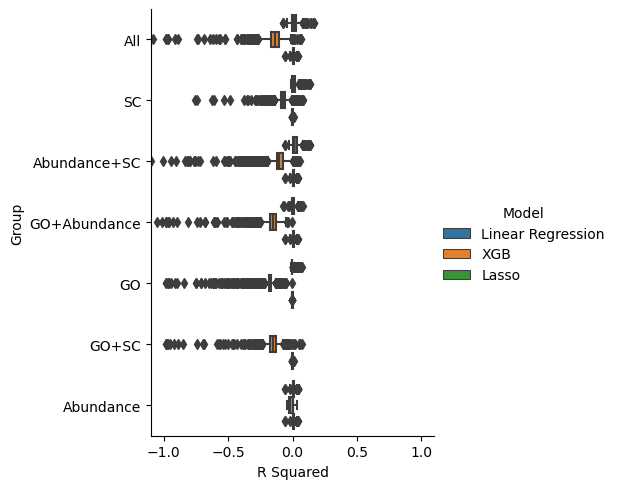

In [17]:
import seaborn as sns

g = sns.catplot(
    data=cv_rsquared_df,
    y='Group',
    x='R Squared',
    hue='Model',
    kind='box'
)
g.set(xlim=(-1.1, 1.1))
#g.set_xticklabels(rotation=10)